# 🛒 Project 2A: 零售运营之术 - 用户分层 (RFM + K-Means)

**真实商业场景**: 
你是某英国跨国电商的 Lead DA。CMO 告诉你：
> "我们有 5000+ 个客户，但我感觉像在对空气营销。有些人只买一次就走了，有些人天天买便宜货。能不能帮我把他们分个类，通过邮件做精准营销？"

**你的任务**:
1.  **数据清洗**: 既然是真实数据，肯定有坑 (退货单、测试单)。
2.  **RFM 计算**: 将 Transaction Data (流水) 转换为 Customer Data (画像)。
3.  **K-Means 聚类**: 用算法自动发现客户群体。
4.  **策略输出**: 告诉 CMO 每一类人该怎么推。

---

In [ ]:
# 🛠️ 1. 数据导入 (Kaggle API)
# 真实世界数据: Online Retail II (UCI ML Repository)
# 包含 2009-2011 年的真实交易记录

# !kaggle datasets download mashlyn/online-retail-ii-uci --path ./data --unzip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
# 加载数据 (注意: 这是一个大文件，可能需要几秒钟)
df = pd.read_csv('./data/online_retail_II.csv')
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 🧹 Module 1: 真实数据的残酷 (Data Cleaning)

别急着做模型。真实数据里充满了 "坑"。

**Checklist**:
1.  **缺失值**: `Customer ID` 为空的数据能用来做用户分层吗？(显然不能，删掉)
2.  **异常值**: `Quantity` < 0 是什么意思？(退货单，C开头的Invoice)。我们需要把它们剔除，或者单独分析。
3.  **数据类型**: `InvoiceDate` 是字符串吗？转成 datetime。

In [ ]:
df_origin = df.copy()

In [ ]:
df.columns = df.columns.str.lower().str.strip().str.replace(r' ','_',regex=True)
df.info()
# 先把customerid转str
df['customer_id'] = df['customer_id'].astype(str)
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   invoice      1067371 non-null  object 
 1   stockcode    1067371 non-null  object 
 2   description  1062989 non-null  object 
 3   quantity     1067371 non-null  int64  
 4   invoicedate  1067371 non-null  object 
 5   price        1067371 non-null  float64
 6   customer_id  824364 non-null   float64
 7   country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stockcode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
invoicedate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
customer_id,1067371,5943,nan,243007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['customer_id'] = df['customer_id'].str.replace('.0','',case=True)
df.loc[df['customer_id'].str.contains('nan')] = np.nan 
df = df.dropna(subset='customer_id')

In [ ]:
df.loc[(df['quantity']<0) | (df['price']<0)] = np.nan
df= df.dropna(subset='price')
df= df.dropna(subset='quantity')


In [ ]:
print("---before---")
df_origin.describe(include='all').T

---before---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,172.705794,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,1697.46445,12346.0,13975.0,15255.0,16797.0,18287.0
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("---after---")
df.describe(include='all').T

---after---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
invoice,805620,36975,576339,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stockcode,805620,4631,85123A,5188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,805620,5283,WHITE HANGING HEART T-LIGHT HOLDER,5181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,805620.0,NaN,NaN,NaN,13.307665,1.0,2.0,5.0,12.0,80995.0,144.306739
invoicedate,805620,NaN,NaN,NaN,2011-01-02 10:26:35.704326144,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-03 15:10:00,2011-07-28 13:28:00,2011-12-09 12:50:00,NaN
price,805620.0,NaN,NaN,NaN,3.206279,0.0,1.25,1.95,3.75,10953.5,29.197901
customer_id,805620,5881,17841,12890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,805620,41,United Kingdom,725296,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 📐 Module 2: RFM 特征工程 (Feature Engineering)

将 "流水表" (Transaction Log) 聚合为 "用户表" (Customer Table)。

*   **R (Recency)**: 最近一次购买距今多少天？(越小越好)
*   **F (Frequency)**: 购买了多少次？(次数，不是商品数)
*   **M (Monetary)**: 一共花了多少钱？(Sum of Sales)

**提示**:
设定一个 `snapshot_date` (通常是数据集最大日期 + 1天)，用它减去每个用户的最大日期得到 Recency。

In [ ]:
snapshot_date=df['invoicedate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
df['recency'] = (pd.to_datetime(snapshot_date) - df['invoicedate']).dt.days + 1
df['sales'] = df['quantity'] * df['price']
df


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,recency,sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085,United Kingdom,739,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,739,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,739,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085,United Kingdom,739,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085,United Kingdom,739,30.00
...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680,France,1,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680,France,1,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680,France,1,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680,France,1,14.85


In [ ]:
customer_summary = df.groupby(['country','customer_id'])[['invoice','quantity','price','sales','invoicedate']].agg(
    last_purchase_date=('invoicedate','max'),
    avg_quantity=('quantity','mean'),
    avg_amount=('sales','mean'),
    monetary=('sales','sum'),
    frequency=('invoice','nunique')
).reset_index()

customer_summary['recency'] = (snapshot_date - customer_summary['last_purchase_date']).dt.days +1
customer_summary

,country,customer_id,last_purchase_date,avg_quantity,avg_amount,monetary,frequency,recency
0,Australia,12386,2011-01-06 12:37:00,31.555556,36.711111,660.80,2,338
1,Australia,12387,2010-10-20 16:27:00,14.888889,15.993333,143.94,1,415
2,Australia,12388,2011-11-24 12:30:00,13.705479,26.719932,3901.11,8,16
3,Australia,12389,2010-11-02 11:52:00,12.530612,29.251633,1433.33,3,403
4,Australia,12392,2010-04-27 14:04:00,10.428571,33.535714,234.75,1,591
...,...,...,...,...,...,...,...,...
5889,Unspecified,12470,2010-01-19 11:01:00,4.130435,9.215217,211.95,1,690
5890,Unspecified,12743,2011-07-28 16:21:00,2.380597,4.077836,546.43,2,134
5891,Unspecified,14265,2011-08-22 13:32:00,9.050633,17.384177,1373.35,4,109
5892,Unspecified,16320,2011-06-20 15:25:00,13.771784,23.356805,5628.99,6,172


## 🤖 Module 3: K-Means 聚类 (Unsupervised Learning)

我们不想手动拍脑袋定义 "什么是高价值" (比如 > 1000元)。我们让数据自己说话。

**步骤**:
1.  **去偏 (Unskew)**: RFM 数据通常是长尾分布 (Right-skewed)，需要 Log Transformation (`np.log1p`)。
2.  **归一化 (Standardize)**: R, F, M 的量纲不同 (天数 vs 金额)，必须用 `StandardScaler`。
3.  **聚类 (Fit)**: 尝试 K=3 或 K=4。

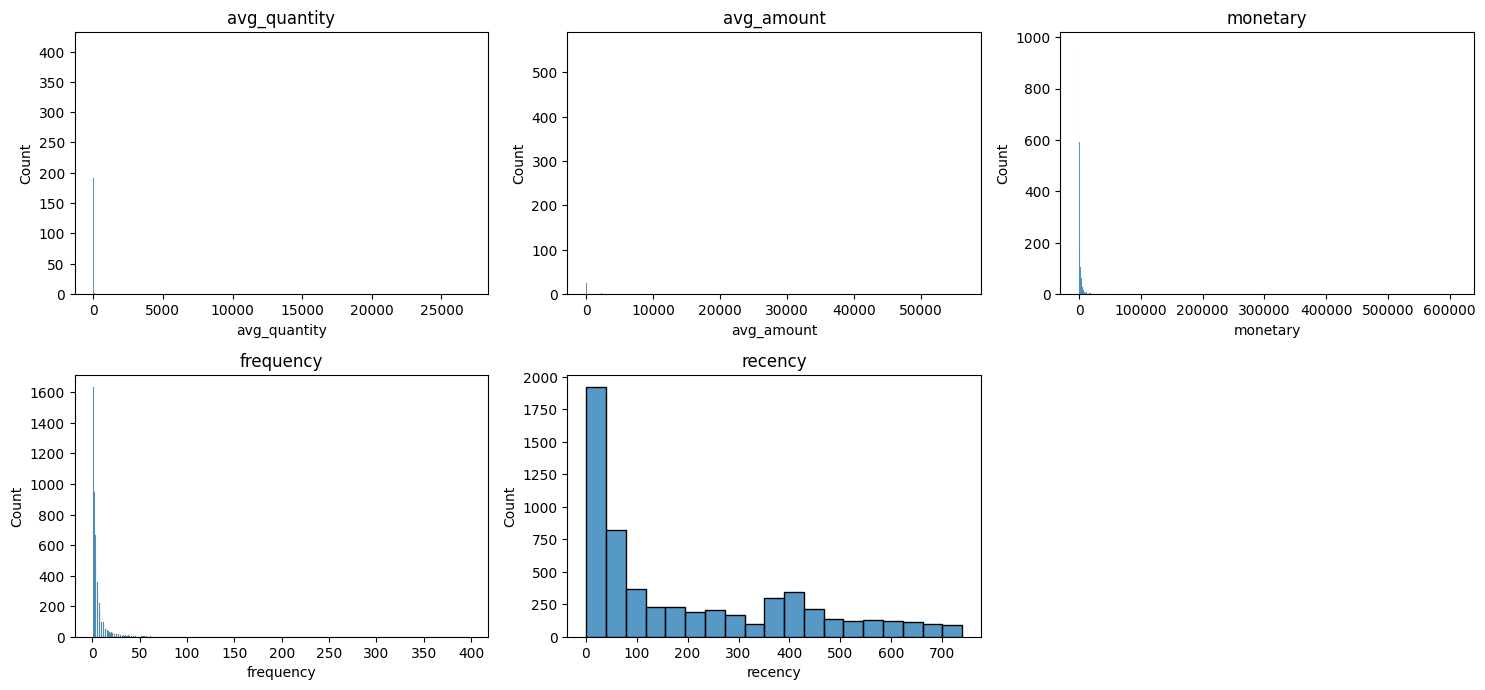

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

processed_customer_summary = customer_summary.copy()

# 1. 自动筛选所有数值列 (排除掉 label)
num_cols = processed_customer_summary.select_dtypes(include=['number']).columns.tolist()

# 2. 循环画图 (subplot)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1) # 假设有9个变量，3x3排列
    sns.histplot(data=processed_customer_summary, x=col) # 对比 label=0/1 的分布差异
    plt.title(col)
plt.tight_layout()

/var/folders/35/q6rh83x91bzgf3gcsb_13f_80000gn/T/ipykernel_57525/2029681775.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
./Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


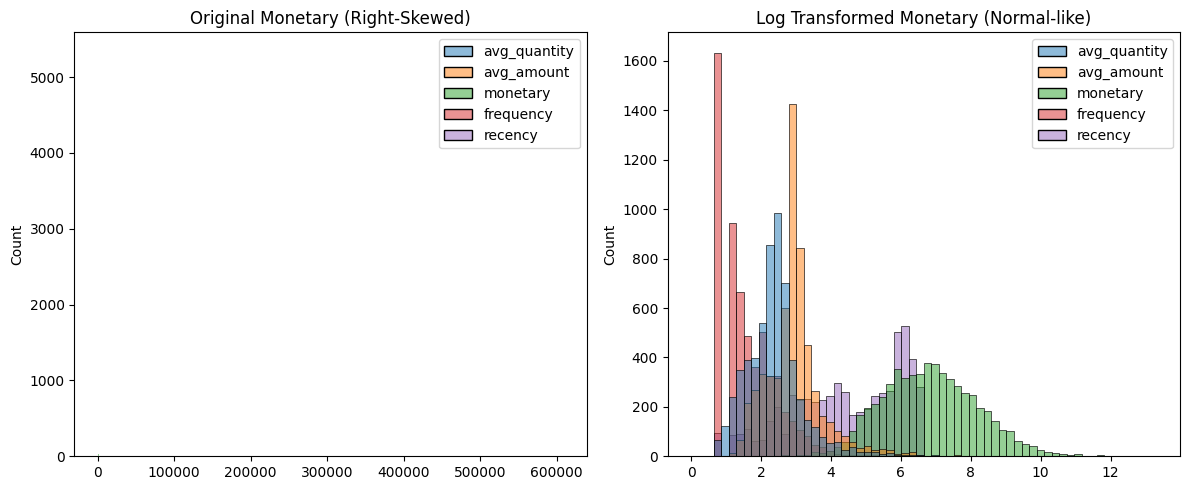

In [30]:
processed_customer_summary= np.log1p(customer_summary[num_cols])

# 📊 可视化：为什么要 Log？
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 图1: 原始数据 (你会发现数据都挤在左边，根本看不清分布)
sns.histplot(customer_summary[num_cols], ax=ax[0])
ax[0].set_title('Original Monetary (Right-Skewed)')

# 图2: Log 变换后 (变成了漂亮的钟形曲线！)
sns.histplot(processed_customer_summary[num_cols], ax=ax[1])
ax[1].set_title('Log Transformed Monetary (Normal-like)')

plt.tight_layout()
plt.show()

In [31]:
corr_matrix = processed_customer_summary.corr(numeric_only=True)
corr_matrix

,avg_quantity,avg_amount,monetary,frequency,recency
avg_quantity,1.000000,0.772663,0.254641,0.108270,-0.060668
avg_amount,0.772663,1.000000,0.262526,0.082584,0.008259
monetary,0.254641,0.262526,1.000000,0.847917,-0.502299
frequency,0.108270,0.082584,0.847917,1.000000,-0.561689
recency,-0.060668,0.008259,-0.502299,-0.561689,1.000000


In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(processed_customer_summary), columns=num_cols)

🏆 最佳 K 值 (Elbow Point) 是: 3


./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sk

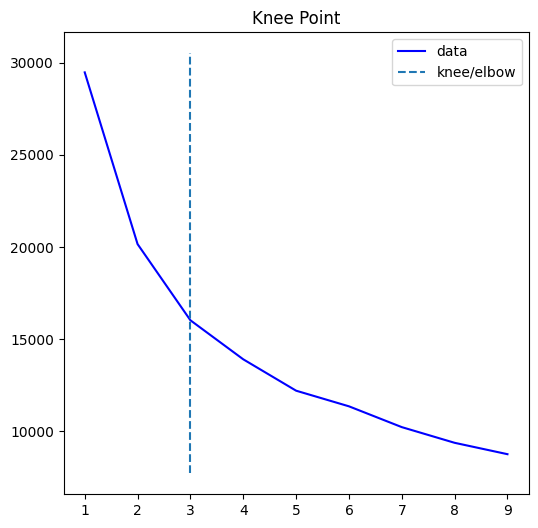

In [33]:
from sklearn.cluster import KMeans

# 1. 肘部法则选 K (Elbow Method) & 自动找拐点 📉
# 需安装: !pip install kneed

from kneed import KneeLocator

sse = []
K_range = range(1, 10)

# 1.1 计算 SSE
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_)

# 1.2 自动寻找 "手肘点" (Elbow Point)
# curve='convex' (凸), direction='decreasing' (下降)
kl = KneeLocator(K_range, sse, curve="convex", direction="decreasing")

print(f"🏆 最佳 K 值 (Elbow Point) 是: {kl.elbow}")
kl.plot_knee()

In [36]:
# 必须先运行这一步，把标签打上！
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)
customer_summary['cluster'] = kmeans.labels_  # <--- 就是缺了这一步！

./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


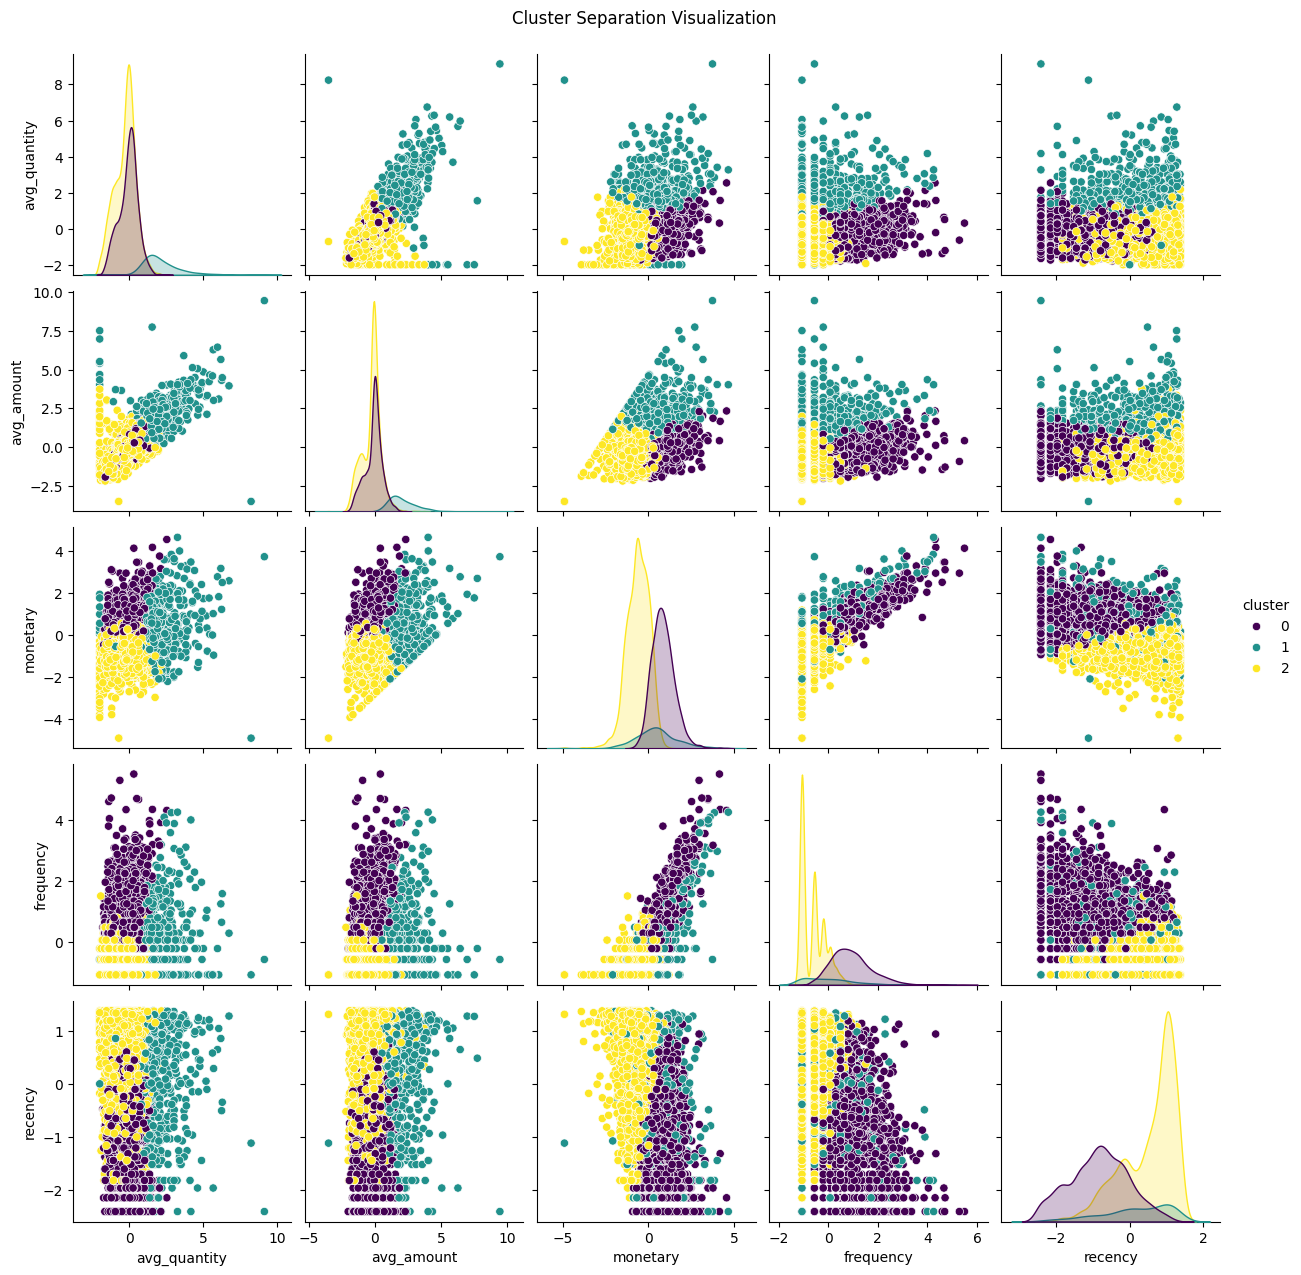

In [37]:
# 1. 把 Cluster 标签拼回到 Scaled 数据里 (方便画图)
df_plot = df_scaled.copy()
df_plot['cluster'] = customer_summary['cluster'].values # 注意要用 .values 对齐索引

# 2. 用 Seaborn 画 Pairplot (两两对比)
# hue='cluster': 按聚类结果上色
# palette='viridis': 颜色盘
sns.pairplot(df_plot, hue='cluster', palette='viridis', diag_kind='kde')
plt.suptitle("Cluster Separation Visualization", y=1.02)
plt.show()

In [38]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df_plot, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.432


./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 📊 Module 4: 业务解读 (Business Insights)

聚类完成后，别只给个 Label (0, 1, 2)。老板看不懂。
你需要计算每组的 **R, F, M 均值**，并给它们起个名字。

例如:
*   **Cluster 0**: R高, F低, M低 -> 沉睡用户 (挽留?)
*   **Cluster 1**: R低, F高, M高 -> 超级VIP (跪舔!)
*   **Cluster 2**: R低, F低, M低 -> 新用户 (促活!)

**可视化**: 使用 Snake Plot (Line Chart) 展示各组的特征差异。

In [39]:
# 1. 把 Cluster 标签拼回原始数据 (customer_summary)
customer_summary['cluster'] = kmeans.labels_

# 2. 算均值 (Profile)
cluster_profile = customer_summary.groupby('cluster')[['avg_amount','avg_quantity' ,'frequency', 'recency', 'monetary']].mean()
cluster_profile['count'] = customer_summary.groupby('cluster')['recency'].count() # 看看每类有多少人
cluster_profile = cluster_profile.reset_index()
cluster_profile


,cluster,avg_amount,avg_quantity,frequency,recency,monetary,count
0,0,19.336595,10.872228,12.372889,47.003283,5353.557140,2132
1,1,361.457993,211.489145,7.491228,217.495127,8813.316963,513
2,2,17.824659,9.215423,2.078486,300.713450,556.606264,3249


In [40]:
cluster_map = {
    0: "活跃忠诚用户 (High F, Low R)",
    1: "高价值流失预警 (High M, High R)",
    2: "低价值流失 (Low M, High R)"
}
cluster_profile['cluster'] = cluster_profile['cluster'].map(cluster_map)
cluster_profile

,cluster,avg_amount,avg_quantity,frequency,recency,monetary,count
0,"活跃忠诚用户 (High F, Low R)",19.336595,10.872228,12.372889,47.003283,5353.557140,2132
1,"高价值流失预警 (High M, High R)",361.457993,211.489145,7.491228,217.495127,8813.316963,513
2,"低价值流失 (Low M, High R)",17.824659,9.215423,2.078486,300.713450,556.606264,3249


./Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
./Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
./Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


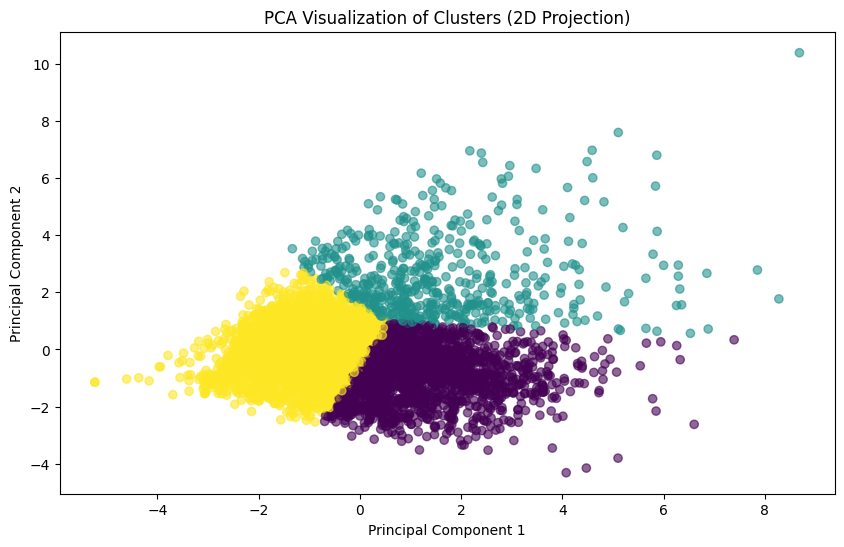

In [41]:
from sklearn.decomposition import PCA

# 1. 降维到 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled) # 记得用 Scaled 数据！

# 2. 画图
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=customer_summary['cluster'], cmap='viridis', alpha=0.6)
plt.title("PCA Visualization of Clusters (2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [42]:
# 1. 自动计算阈值 (动态 Pipeline 的核心)
# R_score: Recency 越小越好 (所以 labels=[5,4,3,2,1])
customer_summary['R_Score'] = pd.qcut(customer_summary['recency'], 5, labels=[5, 4, 3, 2, 1])

# F_score, M_score: 越大越好 (labels=[1,2,3,4,5])
customer_summary['F_Score'] = pd.qcut(customer_summary['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
customer_summary['M_Score'] = pd.qcut(customer_summary['monetary'], 5, labels=[1, 2, 3, 4, 5])

# 2. 算出总分 (3-15分)
customer_summary['Total_Score'] = customer_summary[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print(customer_summary.head())

     country customer_id  last_purchase_date  avg_quantity  avg_amount  \
0  Australia       12386 2011-01-06 12:37:00     31.555556   36.711111   
1  Australia       12387 2010-10-20 16:27:00     14.888889   15.993333   
2  Australia       12388 2011-11-24 12:30:00     13.705479   26.719932   
3  Australia       12389 2010-11-02 11:52:00     12.530612   29.251633   
4  Australia       12392 2010-04-27 14:04:00     10.428571   33.535714   

   monetary  frequency  recency  cluster R_Score F_Score M_Score  Total_Score  
0    660.80          2      338        2       2       2       3            7  
1    143.94          1      415        2       1       1       1            3  
2   3901.11          8       16        0       5       4       5           14  
3   1433.33          3      403        2       2       3       4            9  
4    234.75          1      591        2       1       1       1            3  


In [43]:
# --- Senior Insight: Rule-based Simulation ---
# “算法虽好，但业务有时需要更硬的规则”

# 1. 自动打分 (1-5分)
r_labels = range(5, 0, -1) # R越小越好 (5,4,3,2,1)
f_labels = range(1, 6)     # F越大越好 (1,2,3,4,5)
m_labels = range(1, 6)     # M越大越好

customer_summary['R_Score'] = pd.qcut(customer_summary['recency'], 5, labels=r_labels).astype(int)
customer_summary['F_Score'] = pd.qcut(customer_summary['frequency'].rank(method='first'), 5, labels=f_labels).astype(int)
customer_summary['M_Score'] = pd.qcut(customer_summary['monetary'], 5, labels=m_labels).astype(int)

# 2. 组合 RFM Segment
# 直接把分数组合起来，比如 "555" (R=5, F=5, M=5) 就是顶级用户
customer_summary['RFM_Segment'] = customer_summary['R_Score'].astype(str) + customer_summary['F_Score'].astype(str) + customer_summary['M_Score'].astype(str)

# 3. 计算 "RFM Score" (3-15分)
customer_summary['Total_Score'] = customer_summary[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print("Top Segments (Human Readable):")
print(customer_summary.groupby('RFM_Segment')['monetary'].mean().sort_values(ascending=False).head(10))

Top Segments (Human Readable):
RFM_Segment
525    85832.520000
555    17567.551395
255    13086.806529
155     9204.557000
235     9034.513750
455     8978.895657
125     7581.953333
115     7573.652500
335     7099.968333
145     7092.088182
Name: monetary, dtype: float64
